In [1]:
!pip install yfinance

TASK 2: STOCK PRICE PREDICTION
Predicting Next Day's Closing Price

📈 STEP 1: LOADING STOCK DATA
----------------------------------------
Loading data for: AAPL


[*********************100%***********************]  1 of 1 completed



Data shape: (502, 5)
Date range: 2024-06-04 to 2026-06-04

First 5 rows:
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-06-04  192.680923  193.642594  191.372252  192.968426  47471400
2024-06-05  194.187851  195.209004  193.196439  193.721886  54156800
2024-06-06  192.809814  194.812471  192.502479  194.009430  41181800
2024-06-07  195.199081  195.248655  192.472699  192.978313  53103900
2024-06-10  191.461472  195.605581  190.499801  195.209008  97010200

🔧 STEP 2: PREPARING FEATURES
----------------------------------------
Features created: Open, High, Low, Volume, DayOfWeek, Month, PriceRange, PriceChange, MA_5, MA_10, VolumeChange
Data shape after feature engineering: (493, 13)

🎯 STEP 3: CREATING TARGET VARIABLE
----------------------------------------
Target: Next day's closing price
Final data shape: (492, 14)

📊 ST

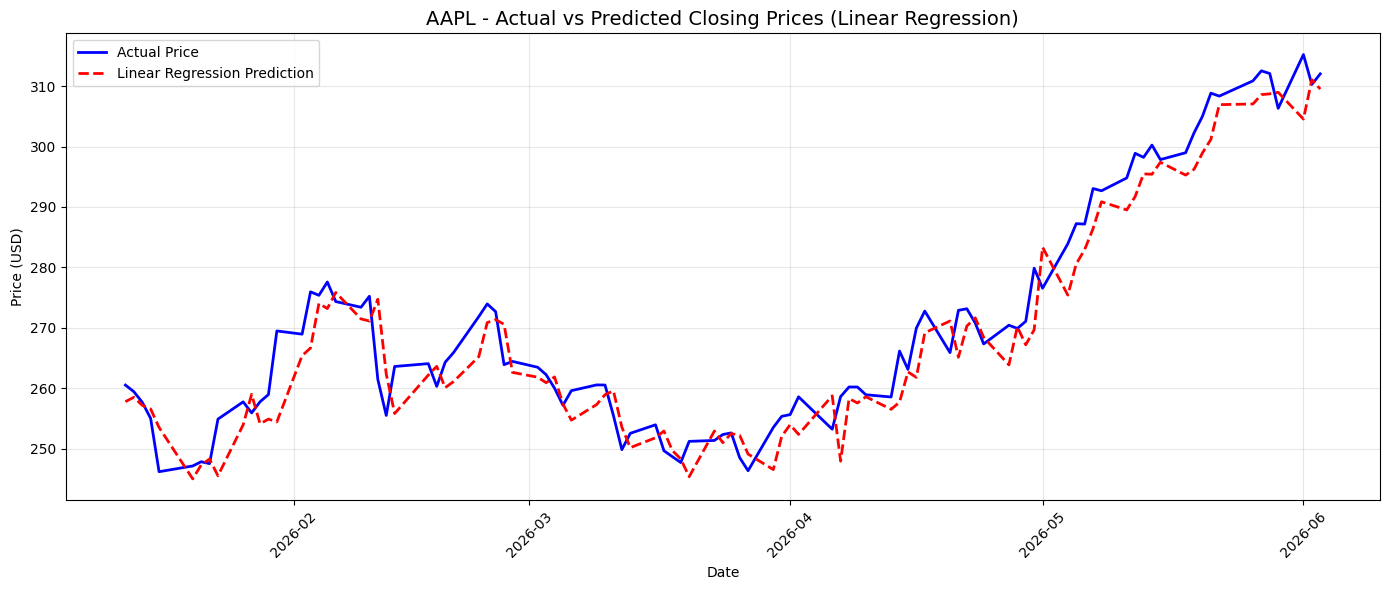

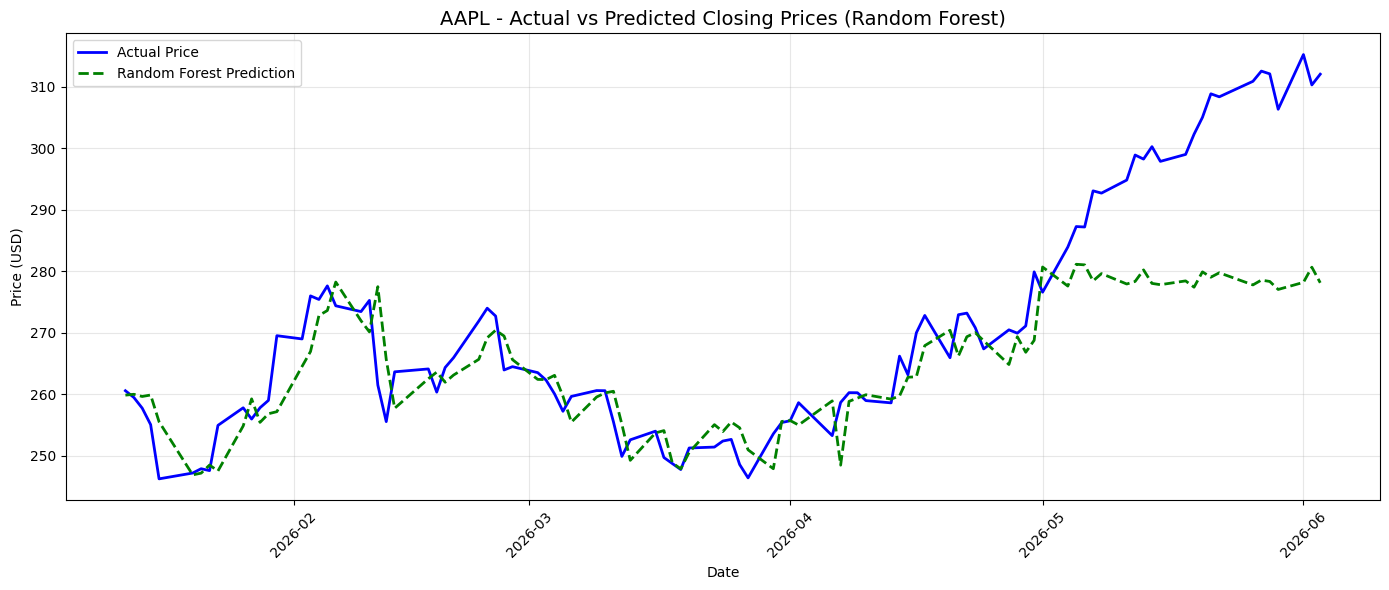

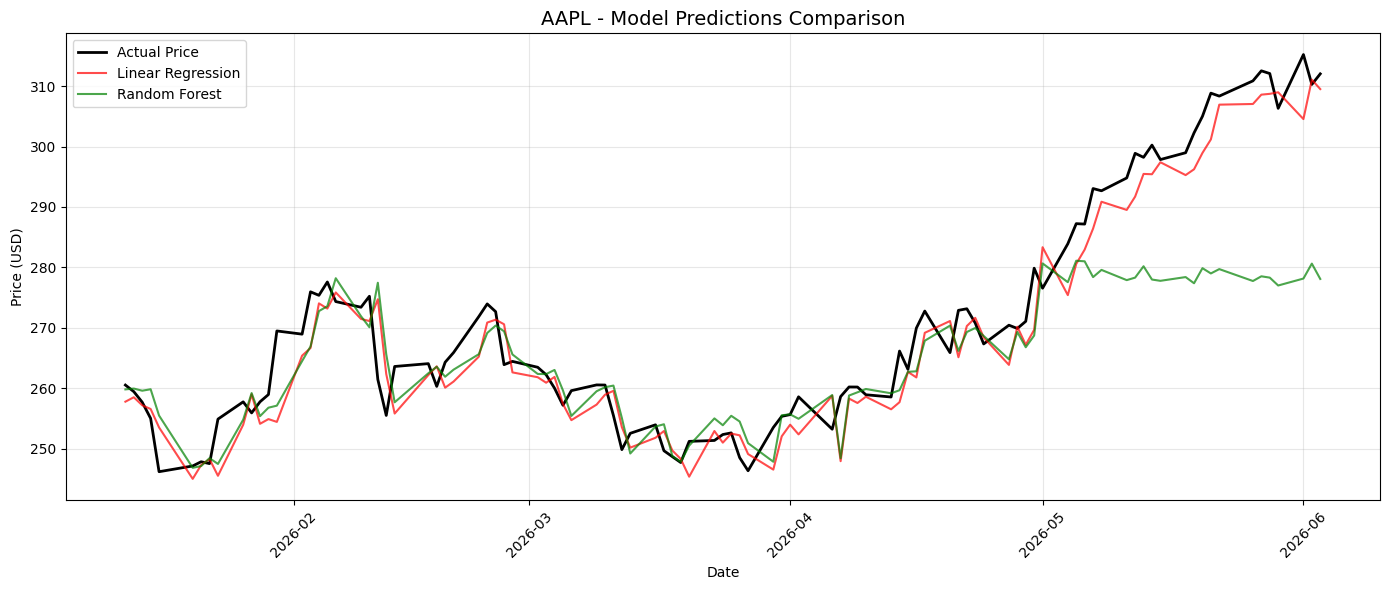

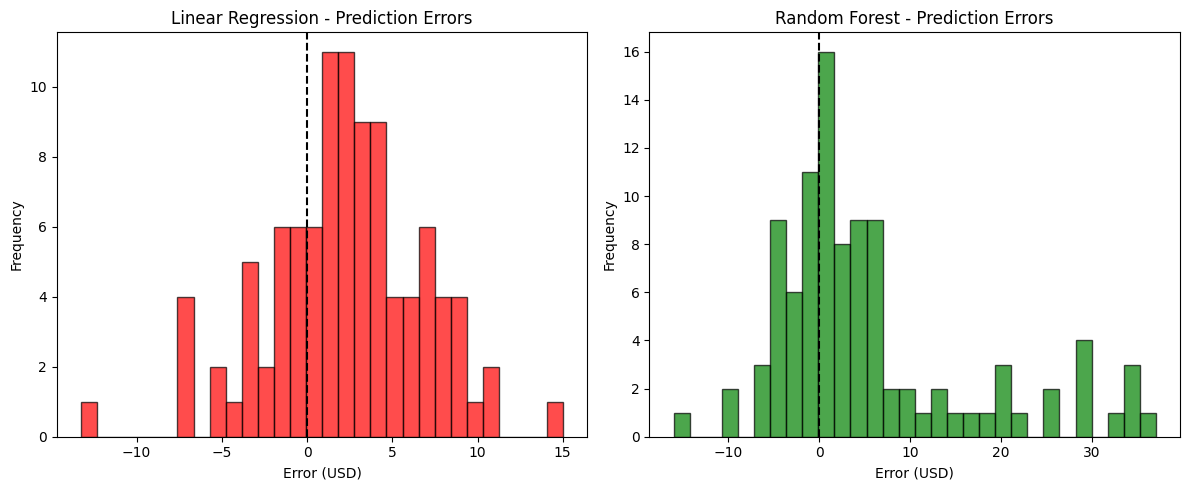


📊 STEP 10: FEATURE IMPORTANCE
----------------------------------------


/tmp/ipykernel_34042/1787592162.py:249: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


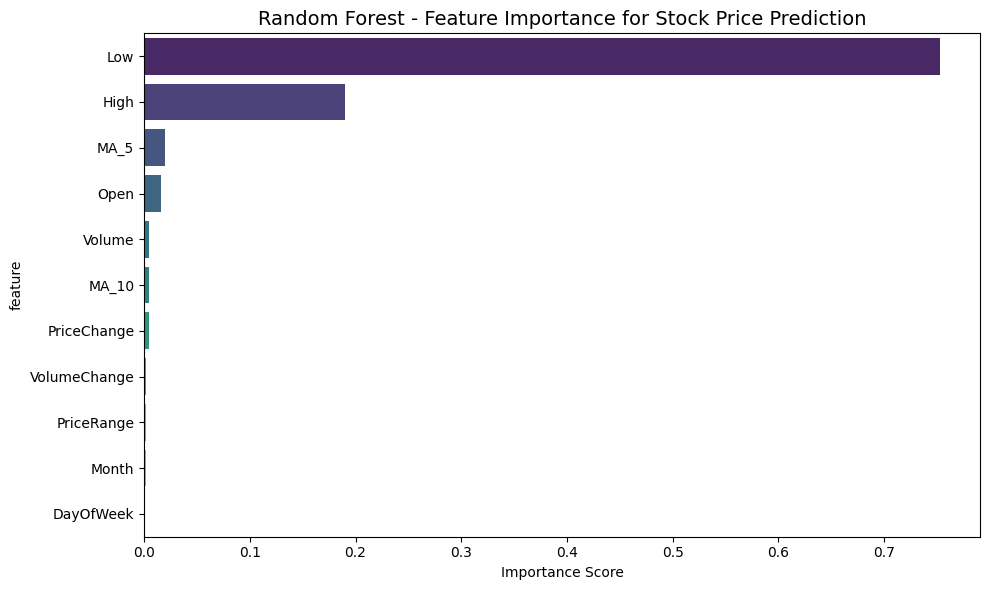


Top 3 most important features:
  1. Low: 0.7529
  2. High: 0.1901
  3. MA_5: 0.0195

🔮 STEP 11: PREDICT TOMORROW'S PRICE
----------------------------------------
Today's closing price (2026-06-03): $310.26
Predicted closing price for tomorrow: $278.10
📉 Predicted: DOWN by $32.16 (10.36%)

📋 FINAL RESULTS SUMMARY

✅ Task Completed: Stock Price Prediction

Stock Information:
- Symbol: AAPL
- Company: Apple Inc.
- Data Period: 2024-06-17 to 2026-06-03
- Total Days: 492

Model Performance (Test Set):
Linear Regression:
  - MAE: $4.03
  - RMSE: $5.03
  - R² Score: 0.9295

Random Forest:
  - MAE: $7.95
  - RMSE: $12.41
  - R² Score: 0.5704

Best Model: Linear Regression

Key Findings:
1. Most important feature: Low
2. Random Forest underperforms compared to Linear Regression
3. Average prediction error: $4.03
4. Tomorrow's predicted price: $278.10

Limitations:
- Stock prices are highly volatile and influenced by external factors
- Model only uses historical price data (no news, sentiment, 

In [5]:
# Task 2: Stock Price Prediction (Next Day Closing Price)
# AI/ML Internship - DevelopersHub Corporation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("="*60)
print("TASK 2: STOCK PRICE PREDICTION")
print("Predicting Next Day's Closing Price")
print("="*60)

# Step 1: Select and Load Stock Data
print("\n📈 STEP 1: LOADING STOCK DATA")
print("-"*40)

# Choose a stock (change this to any stock symbol)
stock_symbol = "AAPL"  # Apple
# Other options: "TSLA" (Tesla), "GOOGL" (Google), "MSFT" (Microsoft)

print(f"Loading data for: {stock_symbol}")

# Download last 2 years of data
stock_data = yf.download(stock_symbol, period="2y", interval="1d", auto_adjust=True)

print(f"\nData shape: {stock_data.shape}")
print(f"Date range: {stock_data.index[0].date()} to {stock_data.index[-1].date()}")
print(f"\nFirst 5 rows:")
print(stock_data.head())

# Step 2: Data Preparation
print("\n🔧 STEP 2: PREPARING FEATURES")
print("-"*40)

# Create a new dataframe for features
df = stock_data.copy()

# Reset index to make Date a column
df.reset_index(inplace=True)

# Create features (using Open, High, Low, Volume)
# We'll also add some technical indicators

# Day of week (0=Monday, 4=Friday)
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Month
df['Month'] = df['Date'].dt.month

# Price range (High - Low)
df['PriceRange'] = df['High'] - df['Low']

# Price change percentage
df['PriceChange'] = df['Close'].pct_change()

# Moving averages
df['MA_5'] = df['Close'].rolling(window=5).mean()  # 5-day moving average
df['MA_10'] = df['Close'].rolling(window=10).mean()  # 10-day moving average

# Volume change
df['VolumeChange'] = df['Volume'].pct_change()

# Drop rows with NaN values (from rolling calculations)
df.dropna(inplace=True)

print(f"Features created: Open, High, Low, Volume, DayOfWeek, Month, PriceRange, PriceChange, MA_5, MA_10, VolumeChange")
print(f"Data shape after feature engineering: {df.shape}")

# Step 3: Create Target Variable (Next Day's Closing Price)
print("\n🎯 STEP 3: CREATING TARGET VARIABLE")
print("-"*40)

# Shift the Close price by -1 to get next day's closing price
df['Next_Close'] = df['Close'].shift(-1)

# Remove the last row (no next day data)
df = df.dropna()

print(f"Target: Next day's closing price")
print(f"Final data shape: {df.shape}")

# Step 4: Select Features and Target
print("\n📊 STEP 4: SELECTING FEATURES")
print("-"*40)

# Feature columns (excluding Date and target)
feature_columns = ['Open', 'High', 'Low', 'Volume',
                   'DayOfWeek', 'Month', 'PriceRange',
                   'PriceChange', 'MA_5', 'MA_10', 'VolumeChange']

X = df[feature_columns]
y = df['Next_Close']

print(f"Features shape: {X.shape}")
print(f"Features used: {feature_columns}")
print(f"Target shape: {y.shape}")

# Step 5: Split Data (Time Series Order - NO SHUFFLING!)
print("\n✂️ STEP 5: TRAIN-TEST SPLIT (Time Series)")
print("-"*40)

# For time series, we don't shuffle! Use chronological order
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

print(f"Training data: {X_train.shape[0]} days ({df['Date'].iloc[:split_index].min().date()} to {df['Date'].iloc[:split_index].max().date()})")
print(f"Test data: {X_test.shape[0]} days ({df['Date'].iloc[split_index].date()} to {df['Date'].iloc[-1].date()})")

# Step 6: Feature Scaling (for better performance)
print("\n📏 STEP 6: FEATURE SCALING")
print("-"*40)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled to mean=0, std=1")

# Step 7: Train Models
print("\n🤖 STEP 7: TRAINING MODELS")
print("-"*40)

# Model 1: Linear Regression
print("\nTraining Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# Model 2: Random Forest
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# Step 8: Evaluate Models
print("\n📊 STEP 8: MODEL EVALUATION")
print("-"*40)

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}:")
    print(f"  MAE (Mean Absolute Error): ${mae:.2f}")
    print(f"  RMSE (Root Mean Square Error): ${rmse:.2f}")
    print(f"  R² Score: {r2:.4f}")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

print("\n" + "="*40)
print("TEST SET PERFORMANCE:")
print("="*40)

lr_metrics = evaluate_model(y_test, lr_pred, "Linear Regression")
rf_metrics = evaluate_model(y_test, rf_pred, "Random Forest")

# Step 9: Visualizations
print("\n📈 STEP 9: VISUALIZATIONS")
print("-"*40)

# Get actual test dates for plotting
test_dates = df['Date'].iloc[split_index:]

# Plot 1: Actual vs Predicted (Linear Regression)
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test, label='Actual Price', color='blue', linewidth=2)
plt.plot(test_dates, lr_pred, label='Linear Regression Prediction', color='red', linestyle='--', linewidth=2)
plt.title(f'{stock_symbol} - Actual vs Predicted Closing Prices (Linear Regression)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Actual vs Predicted (Random Forest)
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test, label='Actual Price', color='blue', linewidth=2)
plt.plot(test_dates, rf_pred, label='Random Forest Prediction', color='green', linestyle='--', linewidth=2)
plt.title(f'{stock_symbol} - Actual vs Predicted Closing Prices (Random Forest)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: Both models comparison
plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test, label='Actual Price', color='black', linewidth=2)
plt.plot(test_dates, lr_pred, label='Linear Regression', color='red', alpha=0.7)
plt.plot(test_dates, rf_pred, label='Random Forest', color='green', alpha=0.7)
plt.title(f'{stock_symbol} - Model Predictions Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 4: Prediction Error Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
lr_errors = y_test - lr_pred
plt.hist(lr_errors, bins=30, edgecolor='black', alpha=0.7, color='red')
plt.title('Linear Regression - Prediction Errors')
plt.xlabel('Error (USD)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='black', linestyle='--')

plt.subplot(1, 2, 2)
rf_errors = y_test - rf_pred
plt.hist(rf_errors, bins=30, edgecolor='black', alpha=0.7, color='green')
plt.title('Random Forest - Prediction Errors')
plt.xlabel('Error (USD)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

# Plot 5: Feature Importance (Random Forest)
print("\n📊 STEP 10: FEATURE IMPORTANCE")
print("-"*40)

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Random Forest - Feature Importance for Stock Price Prediction', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
for i in range(3):
    print(f"  {i+1}. {feature_importance.iloc[i]['feature']}: {feature_importance.iloc[i]['importance']:.4f}")

# Step 11: Next Day Prediction (Bonus)
print("\n🔮 STEP 11: PREDICT TOMORROW'S PRICE")
print("-"*40)

# Get the latest data point
latest_data = X.iloc[-1:].values
latest_data_scaled = scaler.transform(latest_data)

# Predict using Random Forest (better model)
tomorrow_prediction = rf_model.predict(latest_data_scaled)[0]
today_price = df['Close'].iloc[-1].item() # Get scalar value

print(f"Today's closing price ({df['Date'].iloc[-1].date()}): ${today_price:.2f}")
print(f"Predicted closing price for tomorrow: ${tomorrow_prediction:.2f}")

price_change = tomorrow_prediction - today_price
price_change_pct = (price_change / today_price) * 100

if price_change > 0:
    print(f"📈 Predicted: UP by ${price_change:.2f} ({price_change_pct:.2f}%)")
else:
    print(f"📉 Predicted: DOWN by ${abs(price_change):.2f} ({abs(price_change_pct):.2f}%)")

# Final Summary
print("\n" + "="*60)
print("📋 FINAL RESULTS SUMMARY")
print("="*60)

print(f"""
✅ Task Completed: Stock Price Prediction

Stock Information:
- Symbol: {stock_symbol}
- Company: {yf.Ticker(stock_symbol).info.get('longName', 'N/A')}
- Data Period: {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}
- Total Days: {len(df)}

Model Performance (Test Set):
Linear Regression:
  - MAE: ${lr_metrics['MAE']:.2f}
  - RMSE: ${lr_metrics['RMSE']:.2f}
  - R² Score: {lr_metrics['R2']:.4f}

Random Forest:
  - MAE: ${rf_metrics['MAE']:.2f}
  - RMSE: ${rf_metrics['RMSE']:.2f}
  - R² Score: {rf_metrics['R2']:.4f}

Best Model: {'Random Forest' if rf_metrics['R2'] > lr_metrics['R2'] else 'Linear Regression'}

Key Findings:
1. Most important feature: {feature_importance.iloc[0]['feature']}
2. Random Forest {('outperforms' if rf_metrics['R2'] > lr_metrics['R2'] else 'underperforms compared to')} Linear Regression
3. Average prediction error: ${min(lr_metrics['MAE'], rf_metrics['MAE']):.2f}
4. Tomorrow's predicted price: ${tomorrow_prediction:.2f}

Limitations:
- Stock prices are highly volatile and influenced by external factors
- Model only uses historical price data (no news, sentiment, etc.)
- Past performance doesn't guarantee future results

Next Steps for Improvement:
- Add more features (trading volume indicators, sentiment analysis)
- Try LSTM (deep learning for time series)
- Include market indices (S&P500, NASDAQ)
""")
